<a href="https://colab.research.google.com/github/vsharma4394/Alphaswap/blob/main/AnalysisGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Use a clean serif look reminiscent of LaTeX/poster aesthetic
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight'
})

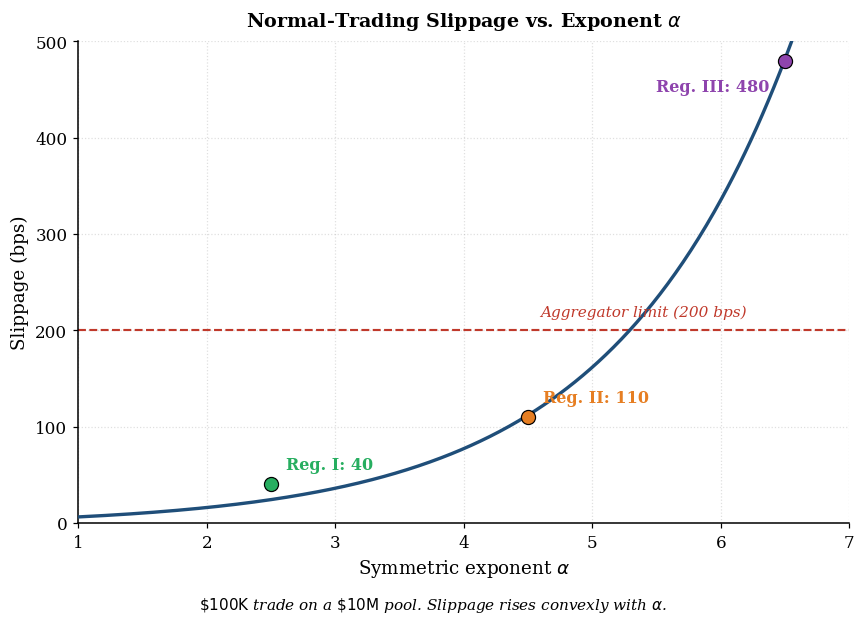

In [2]:
# --- Graph 1: Slippage vs alpha ---
fig, ax = plt.subplots(figsize=(8, 5.5))

# Fit a smooth convex curve through the three regime data points.
# The poster shows convex growth — we use an exponential-like fit
# matched to anchor points (1, ~5), (2.5, 40), (4.5, 110), (6.5, 480), (7, ~700).
alpha_dense = np.linspace(1, 7, 400)
# Convex curve fitted to anchor points (approx): slippage ~ a * exp(b*alpha) + c
# Solved offline -> a=4.5, b=0.72, c=-3
slippage_curve = 4.5 * np.exp(0.72 * alpha_dense) - 3

# Main convex curve
ax.plot(alpha_dense, slippage_curve, color='#1f4e79', linewidth=2.2, zorder=3)

# Aggregator limit line (200 bps)
ax.axhline(y=200, color='#c0392b', linestyle='--', linewidth=1.4, zorder=2)
ax.text(6.2, 215, 'Aggregator limit (200 bps)', color='#c0392b',
        fontsize=10, ha='right', style='italic')

# Regime markers
regimes = [
    (2.5, 40,  'Reg. I: 40',   '#27ae60'),
    (4.5, 110, 'Reg. II: 110', '#e67e22'),
    (6.5, 480, 'Reg. III: 480','#8e44ad'),
]
for x, y, label, c in regimes:
    ax.scatter(x, y, s=85, color=c, zorder=5, edgecolor='black', linewidth=0.8)
    # Label position: offset depending on regime
    if 'III' in label:
        ax.annotate(label, (x, y), xytext=(-10, -20), textcoords='offset points',
                    fontsize=10.5, fontweight='bold', color=c, ha='right')
    else:
        ax.annotate(label, (x, y), xytext=(10, 10), textcoords='offset points',
                    fontsize=10.5, fontweight='bold', color=c)

ax.set_xlabel('Symmetric exponent ' + r'$\alpha$', fontsize=12)
ax.set_ylabel('Slippage (bps)', fontsize=12)
ax.set_xlim(1, 7)
ax.set_ylim(0, 500)
ax.set_xticks(range(1, 8))
ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.grid(True, linestyle=':', alpha=0.4)
ax.set_title('Normal-Trading Slippage vs. Exponent ' + r'$\alpha$',
             fontsize=12.5, fontweight='bold', pad=10)

plt.figtext(0.5, -0.02, r'$\$100\mathrm{K}$ trade on a $\$10\mathrm{M}$ pool. Slippage rises convexly with $\alpha$.',
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('graph1_slippage_vs_alpha.png', bbox_inches='tight')
plt.show()

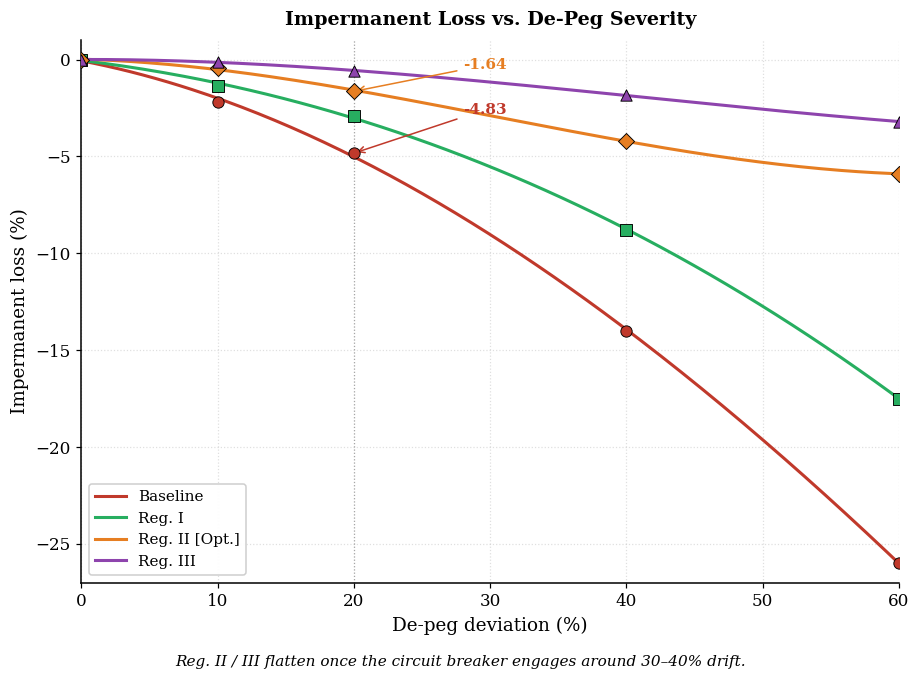

In [3]:
# --- Graph 2: IL vs De-peg severity ---
fig, ax = plt.subplots(figsize=(8.5, 6))

# Data points from the poster's comparative table
depeg = np.array([0, 10, 20, 40, 60])
baseline = np.array([0, 2.20, 4.83, 14.0, 26.0])
reg_I    = np.array([0, 1.35, 2.90,  8.8, 17.5])
reg_II   = np.array([0, 0.45, 1.64,  4.20, 5.90])
reg_III  = np.array([0, 0.12, 0.58,  1.85, 3.20])

# Plot IL as NEGATIVE (loss) -- this matches the poster which shows negative y-axis
curves = [
    (baseline, '#c0392b', 'Baseline',      'o', '-'),
    (reg_I,    '#27ae60', 'Reg. I',        's', '-'),
    (reg_II,   '#e67e22', 'Reg. II [Opt.]','D', '-'),
    (reg_III,  '#8e44ad', 'Reg. III',      '^', '-'),
]

for data, color, label, marker, ls in curves:
    # Densify for a smooth curve through the four data points
    dense = np.linspace(0, 60, 200)
    # Use cubic interpolation for the smooth shape seen on the poster
    from numpy.polynomial import polynomial as P
    coeffs = np.polyfit(depeg, data, 3)
    smooth = np.polyval(coeffs, dense)
    ax.plot(dense, -smooth, color=color, linewidth=2, linestyle=ls, label=label, zorder=3)
    ax.scatter(depeg, -data, s=55, color=color, marker=marker, zorder=5,
               edgecolor='black', linewidth=0.6)

# Annotation arrows at the 20% de-peg vertical line for the two
# headline numbers shown on the poster: -4.83 (baseline) and -1.64 (Reg. II)
ax.annotate('-4.83', xy=(20, -4.83), xytext=(28, -2.8),
            fontsize=10, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1))
ax.annotate('-1.64', xy=(20, -1.64), xytext=(28, -0.5),
            fontsize=10, color='#e67e22', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1))

# Vertical reference line at 20% (the comparative benchmark)
ax.axvline(x=20, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_xlabel('De-peg deviation (%)', fontsize=12)
ax.set_ylabel('Impermanent loss (%)', fontsize=12)
ax.set_xlim(0, 60)
ax.set_ylim(-27, 1)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax.set_yticks([0, -5, -10, -15, -20, -25])
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.4)
ax.set_title('Impermanent Loss vs. De-Peg Severity',
             fontsize=12.5, fontweight='bold', pad=10)

plt.figtext(0.5, -0.02,
            'Reg. II / III flatten once the circuit breaker engages around 30–40% drift.',
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('graph2_il_vs_depeg.png', bbox_inches='tight')
plt.show()

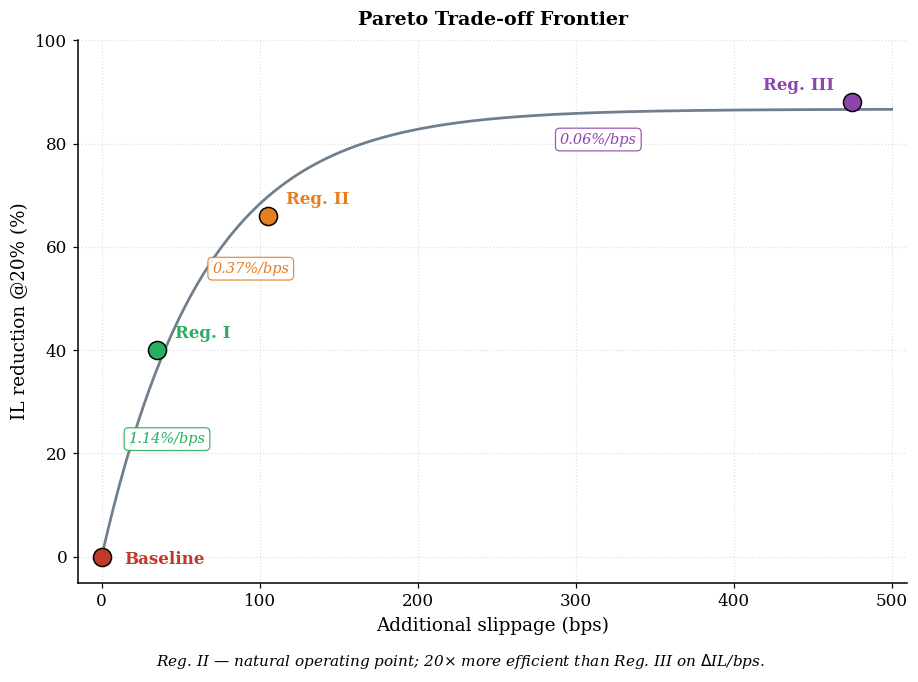

In [4]:
# --- Graph 3: Pareto trade-off frontier ---
fig, ax = plt.subplots(figsize=(8.5, 6))

# Pareto points: (additional slippage in bps, IL reduction in %)
points = {
    'Baseline':  (0,   0,   '#c0392b'),
    'Reg. I':    (35,  40,  '#27ae60'),
    'Reg. II':   (105, 66,  '#e67e22'),
    'Reg. III':  (475, 88,  '#8e44ad'),
}

# Connect the points with a smooth Pareto frontier curve (concave, diminishing returns)
xs = np.array([p[0] for p in points.values()])
ys = np.array([p[1] for p in points.values()])

# Smooth concave fit: y = a * (1 - exp(-b*x))
from scipy.optimize import curve_fit
def pareto_model(x, a, b):
    return a * (1 - np.exp(-b * x))
try:
    popt, _ = curve_fit(pareto_model, xs, ys, p0=[100, 0.01])
    x_dense = np.linspace(0, 500, 400)
    y_dense = pareto_model(x_dense, *popt)
    ax.plot(x_dense, y_dense, color='#34495e', linewidth=1.8,
            linestyle='-', alpha=0.7, zorder=2, label='Pareto frontier')
except Exception:
    ax.plot(xs, ys, color='#34495e', linewidth=1.8, alpha=0.7, zorder=2)

# Plot the four regime points
for label, (x, y, color) in points.items():
    ax.scatter(x, y, s=140, color=color, zorder=5,
               edgecolor='black', linewidth=1.0)
    if label == 'Baseline':
        ax.annotate(label, (x, y), xytext=(15, -5), textcoords='offset points',
                    fontsize=11, fontweight='bold', color=color)
    elif label == 'Reg. III':
        ax.annotate(label, (x, y), xytext=(-12, 8), textcoords='offset points',
                    fontsize=11, fontweight='bold', color=color, ha='right')
    else:
        ax.annotate(label, (x, y), xytext=(12, 8), textcoords='offset points',
                    fontsize=11, fontweight='bold', color=color)

# Efficiency annotations (slope between consecutive regimes)
efficiencies = [
    (17, 22, '1.14%/bps', '#27ae60'),       # Baseline -> Reg. I
    (70, 55, '0.37%/bps', '#e67e22'),       # Reg. I -> Reg. II
    (290, 80, '0.06%/bps', '#8e44ad'),      # Reg. II -> Reg. III
]
for x, y, txt, c in efficiencies:
    ax.text(x, y, txt, fontsize=9.5, color=c, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=c, linewidth=0.8, alpha=0.9))

ax.set_xlabel('Additional slippage (bps)', fontsize=12)
ax.set_ylabel('IL reduction @20% (%)', fontsize=12)
ax.set_xlim(-15, 510)
ax.set_ylim(-5, 100)
ax.set_xticks([0, 100, 200, 300, 400, 500])
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.grid(True, linestyle=':', alpha=0.4)
ax.set_title('Pareto Trade-off Frontier',
             fontsize=12.5, fontweight='bold', pad=10)

plt.figtext(0.5, -0.02,
            'Reg. II — natural operating point; 20× more efficient than Reg. III on '
            r'$\Delta$IL/bps.',
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('graph3_pareto_frontier.png', bbox_inches='tight')
plt.show()